# UCS420 Lab Assignment 9 — NLP Text Preprocessing
Enter your roll number and name, then run all cells.

In [1]:
ROLL_NO = 1024160010
NAME = "Arnav Agarwal"

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"


### Dataset generator — do not modify

In [2]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

### Preprocessing pipeline — do not modify

In [3]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [4]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024160010   Name: Arnav Agarwal   Fingerprint: C7C977D2   Tickets: 12

Ticket_ID                                                                                 Ticket_Text
      T01                                                               Version 2.0.1 crashes at 99%.
      T02                                                       The Wi-Fi works, but the VPN doesn't.
      T03            I cannot access the Python while uploading the file. I have tried several times!
      T04                                                Call me on +91 98765 43210 or 0175-239-3201.
      T05                                The Matlab was working yesterday. I don't know what changed.
      T06                                                             Is it fixed?? Pls reply ASAP :(
      T07     I keep getting logged out of the Matlab since yesterday. The same problem occurs again.
      T08                             The projector stopped responding. It works on another compute

---
## Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row.

In [5]:
import pandas as pd

processed = [process_ticket(text) for text in df["Ticket_Text"]]
rows = []
for ticket_id, result in zip(df["Ticket_ID"], processed):
    rows.append({
        "Ticket_ID": ticket_id,
        "Sentences": len(result["sentences"]),
        "Tokens": len(result["tokens"]),
        "Punctuation": len(result["punct"]),
        "Stopwords": len(result["stops"]),
        "Unique tokens": len(set(result["tokens"])),
        "Final tokens": len(result["final"])
    })
total_row = {
    "Ticket_ID": "TOTAL",
    "Sentences": sum(len(x["sentences"]) for x in processed),
    "Tokens": sum(len(x["tokens"]) for x in processed),
    "Punctuation": sum(len(x["punct"]) for x in processed),
    "Stopwords": sum(len(x["stops"]) for x in processed),
    "Unique tokens": len(set(t for x in processed for t in x["tokens"])),
    "Final tokens": sum(len(x["final"]) for x in processed)
}
q1_table = pd.DataFrame(rows + [total_row])
display(q1_table)

selected_id = FOCUS[0]
selected = processed[df.index[df["Ticket_ID"] == selected_id][0]]
print("Selected ticket:", selected_id)
print("Text:", df.loc[df["Ticket_ID"] == selected_id, "Ticket_Text"].iloc[0])
print("Tokens:", selected["tokens"])
print("Punctuation:", selected["punct"])
print("Stopwords:", selected["stops"])
print("Final tokens:", selected["final"])


,Ticket_ID,Sentences,Tokens,Punctuation,Stopwords,Unique tokens,Final tokens
0,T01,1,7,2,1,7,4
1,T02,1,10,2,4,9,4
2,T03,2,17,2,8,15,7
3,T04,1,9,1,3,9,5
4,T05,2,13,2,5,12,6
5,T06,2,10,4,2,9,4
6,T07,2,17,2,7,15,8
7,T08,2,11,2,3,10,6
8,T09,2,16,2,6,15,8
9,T10,2,21,2,9,17,10


Selected ticket: T08
Text: The projector stopped responding. It works on another computer.
Tokens: ['the', 'projector', 'stopped', 'responding', '.', 'it', 'works', 'on', 'another', 'computer', '.']
Punctuation: ['.', '.']
Stopwords: ['the', 'it', 'on']
Final tokens: ['projector', 'stopped', 'responding', 'works', 'another', 'computer']


**Answer:** Tokens such as `n't`, `'s`, and `ca` come from contractions split by `word_tokenize`.


---
## Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with <EMAIL>, URLs with <URL> and phone numbers with <PHONE>. Your patterns must also work on TEST_LINES (given in the notebook).

In [6]:
TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.",
]

import re
from IPython.display import display

raw_texts = df["Ticket_Text"].tolist()
long_words = [[x for x in re.findall(r"\b[A-Za-z]+\b", text) if len(x) > 5] for text in raw_texts]
numbers = [re.findall(r"(?<![\w.])\d+(?:\.\d+)+(?![\w.])|\b\d+\b", text) for text in raw_texts]
capitalized = [re.findall(r"\b[A-Z][a-zA-Z]*\b", text) for text in raw_texts]
vowel_words = [re.findall(r"\b[aeiouAEIOU][A-Za-z]*\b", text) for text in raw_texts]

def replace_patterns(text):
    text = re.sub(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b", "<EMAIL>", text)
    text = re.sub(r"\b(?:https?://|www\.)[^\s]+", "<URL>", text)
    text = re.sub(r"(?<!\w)(?:\+?\d{1,3}[ -]?)?(?:\(?\d{3,5}\)?[ -]?)?\d{3,5}[ -]\d{4}(?!\w)", "<PHONE>", text)
    return text

q2_table = pd.DataFrame({
    "Ticket_ID": df["Ticket_ID"],
    "Words >5 letters": long_words,
    "Numbers": numbers,
    "Capitalized words": capitalized,
    "Vowel-start words": vowel_words,
    "Replaced text": [replace_patterns(t) for t in raw_texts]
})
display(q2_table)
sentence_initial_words = []
for text in raw_texts:
    for sentence in re.split(r"(?<=[.!?])\\s+", text):
        match = re.search(r"\\b[A-Z][a-zA-Z]*\\b", sentence)
        if match:
            sentence_initial_words.append(match.group())
print("Capitalized words occurring at sentence starts:", len(sentence_initial_words))
test_replacements = pd.DataFrame({"TEST_LINE": TEST_LINES, "Replaced": [replace_patterns(t) for t in TEST_LINES]})
display(test_replacements)


,Ticket_ID,Words >5 letters,Numbers,Capitalized words,Vowel-start words,Replaced text
0,T01,"[Version, crashes]","[2.0.1, 99]",[Version],[at],Version 2.0.1 crashes at 99%.
1,T02,[],[],"[The, Wi, Fi, VPN]",[],"The Wi-Fi works, but the VPN doesn't."
2,T03,"[cannot, access, Python, uploading, several]",[],"[I, Python, I]","[I, access, uploading, I]",I cannot access the Python while uploading the...
3,T04,[],"[91, 98765, 43210, 0175, 239, 3201]",[Call],"[on, or]",Call me on +91 98765 43210 or <PHONE>.
4,T05,"[Matlab, working, yesterday, changed]",[],"[The, Matlab, I]",[I],The Matlab was working yesterday. I don't know...
5,T06,[],[],"[Is, Pls, ASAP]","[Is, it, ASAP]",Is it fixed?? Pls reply ASAP :(
6,T07,"[getting, logged, Matlab, yesterday, problem, ...",[],"[I, Matlab, The]","[I, out, of, occurs, again]",I keep getting logged out of the Matlab since ...
7,T08,"[projector, stopped, responding, another, comp...",[],"[The, It]","[It, on, another]",The projector stopped responding. It works on ...
8,T09,"[Password, stopped, syncing, connected, campus...",[],"[Password, Wi, Fi, The]","[occurs, again]",Password has stopped syncing when connected to...
9,T10,"[unable, student, portal, mobile, hotspot, cha...",[],"[I, I, I]","[I, am, unable, use, I, use, I]",I am unable to use the student portal when I u...


Capitalized words occurring at sentence starts: 0


,TEST_LINE,Replaced
0,Mail it.helpdesk@thapar.edu or a.b-c@dept.univ...,Mail <EMAIL> or <EMAIL>; visit <URL> or <URL>
1,"Call +91 98765 43210, +91-98765-43210 or 0175-...","Call +91 98765 43210, +91-98765-43210 or <PHON..."
2,The state-of-the-art lab isn't open; log-in at...,The state-of-the-art lab isn't open; log-in at...


**Answer:** The count of sentence-initial capitalized words is printed above.


---
## Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.

In [7]:
from nltk.tokenize import RegexpTokenizer, word_tokenize

pattern = r"https?://[^\s]+|www\.[^\s]+|[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}|(?:\+?\d{1,3}[ -]?)?(?:\(?\d{3,5}\)?[ -]?)?\d{3,5}[ -]\d{4}|\b\d+(?:\.\d+)+\b|\b\d+\.\d+\b|\b\d+\b|\b[A-Za-z]+(?:['’][A-Za-z]+)+\b|\b[A-Za-z]+(?:-[A-Za-z]+)+\b|[A-Za-z]+|[^\w\s]"
tokenizer = RegexpTokenizer(pattern)

def my_tokenize(text):
    return tokenizer.tokenize(text)

test_token_table = pd.DataFrame({
    "Text": TEST_LINES,
    "Custom tokens": [my_tokenize(t) for t in TEST_LINES],
    "word_tokenize": [word_tokenize(t) for t in TEST_LINES]
})
display(test_token_table)

custom_tickets = [my_tokenize(t) for t in raw_texts]
word_tickets = [word_tokenize(t) for t in raw_texts]
different_tickets = [
    df.iloc[i]["Ticket_ID"] for i, (a, b) in enumerate(zip(custom_tickets, word_tickets)) if a != b
]
print("Tickets tokenized differently:", len(different_tickets), different_tickets)


,Text,Custom tokens,word_tokenize
0,Mail it.helpdesk@thapar.edu or a.b-c@dept.univ...,"[Mail, it.helpdesk@thapar.edu, or, a.b-c@dept....","[Mail, it.helpdesk, @, thapar.edu, or, a.b-c, ..."
1,"Call +91 98765 43210, +91-98765-43210 or 0175-...","[Call, +91 98765 4321, ,, +91-98765-4321, or, ...","[Call, +91, 98765, 43210, ,, +91-98765-43210, ..."
2,The state-of-the-art lab isn't open; log-in at...,"[The, state-of-the-art, lab, isn't, open, ;, l...","[The, state-of-the-art, lab, is, n't, open, ;,..."


Tickets tokenized differently: 6 ['T02', 'T03', 'T04', 'T05', 'T10', 'T11']


**Answer:** Differences mainly come from keeping contractions, hyphenated terms, URLs, emails, phone numbers, and version numbers together.


---
## Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.

In [8]:
from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer, WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

unique_final = sorted(set(t for result in processed for t in result["final"]))
porter = PorterStemmer()
lancaster = LancasterStemmer()
regexp_stemmer = RegexpStemmer("ing$", min=4)
lemmatizer = WordNetLemmatizer()

def wordnet_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    if tag.startswith("V"):
        return wordnet.VERB
    if tag.startswith("N"):
        return wordnet.NOUN
    if tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN

tagged = dict(pos_tag(unique_final))
stem_rows = []
for word in unique_final:
    pos = wordnet_pos(tagged[word])
    values = {
        "Word": word,
        "Porter": porter.stem(word),
        "Lancaster": lancaster.stem(word),
        "Regexp": regexp_stemmer.stem(word),
        "WordNet lemma": lemmatizer.lemmatize(word, pos)
    }
    if len(set(values.values())) > 1:
        stem_rows.append(values)
stem_table = pd.DataFrame(stem_rows)
display(stem_table)
over_candidates = [row for row in stem_rows if row["Porter"] != row["Word"] and row["WordNet lemma"] == row["Word"]]
under_candidates = [row for row in stem_rows if row["Porter"] == row["Word"] and row["WordNet lemma"] != row["Word"]]
print("Over-stemming candidate:", over_candidates[0] if over_candidates else "No example found")
print("Under-stemming candidate:", under_candidates[0] if under_candidates else "No example found")


,Word,Porter,Lancaster,Regexp,WordNet lemma
0,another,anoth,anoth,another,another
1,assignment,assign,assign,assignment,assignment
2,call,call,cal,call,call
3,campus,campu,camp,campus,campus
4,changed,chang,chang,changed,change
5,computer,comput,comput,computer,computer
6,connected,connect,connect,connected,connect
7,crashes,crash,crash,crashes,crash
8,deadline,deadlin,deadlin,deadline,deadline
9,error,error,er,error,error


Over-stemming candidate: {'Word': 'another', 'Porter': 'anoth', 'Lancaster': 'anoth', 'Regexp': 'another', 'WordNet lemma': 'another'}
Under-stemming candidate: {'Word': 'latest', 'Porter': 'latest', 'Lancaster': 'latest', 'Regexp': 'latest', 'WordNet lemma': 'late'}


**Answer:** Use the over-stemming and under-stemming examples printed above.


---
## Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

,Total tokens,Unique tokens,TTR
S1,162.0,92.0,0.567901
S2,137.0,85.0,0.620438
S3,78.0,57.0,0.730769
S4,78.0,55.0,0.705128


Top 10 words of S1: [('.', 18), ('the', 12), ('i', 8), ("n't", 4), ('yesterday', 4), ('do', 3), ('know', 3), ('what', 3), ('changed', 3), ('it', 3)]
Top 10 words of S3: [("n't", 4), ('yesterday', 4), ('know', 3), ('changed', 3), ('wi-fi', 2), ('works', 2), ('matlab', 2), ('working', 2), ('problem', 2), ('occurs', 2)]


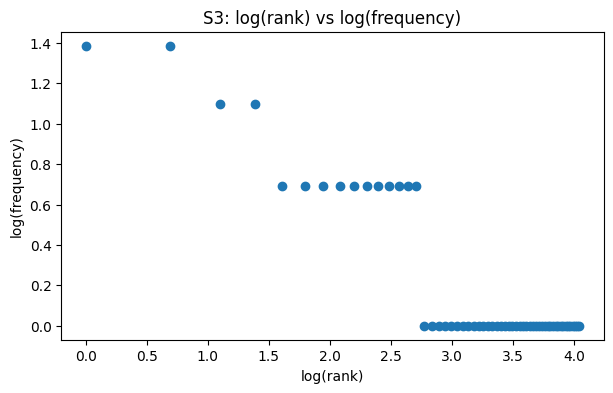

Top 5 bigrams of S1: [(('.', 'i'), 6), (('.', 'the'), 5), (('yesterday', '.'), 3), (('i', 'do'), 3), (('do', "n't"), 3)]
Top 5 bigrams of S3: [(("n't", 'know'), 3), (('know', 'changed'), 3), (('working', 'yesterday'), 2), (('problem', 'occurs'), 2), (('student', 'portal'), 2)]


In [9]:
from collections import Counter
from nltk.util import bigrams
import numpy as np
import matplotlib.pyplot as plt

S1 = [t.lower() for result in processed for t in result["tokens"]]
S2 = [t for t in S1 if not is_punct(t)]
S3 = [t for result in processed for t in result["final"]]
S4 = [porter.stem(t) for t in S3]

def corpus_stats(tokens):
    return {"Total tokens": len(tokens), "Unique tokens": len(set(tokens)),
            "TTR": len(set(tokens)) / len(tokens) if tokens else 0}

stats = pd.DataFrame({
    "S1": corpus_stats(S1),
    "S2": corpus_stats(S2),
    "S3": corpus_stats(S3),
    "S4": corpus_stats(S4)
}).T
display(stats)

print("Top 10 words of S1:", Counter(S1).most_common(10))
print("Top 10 words of S3:", Counter(S3).most_common(10))

freq_s3 = Counter(S3).most_common()
ranks = np.arange(1, len(freq_s3) + 1)
frequencies = np.array([count for _, count in freq_s3])
plt.figure(figsize=(7, 4))
plt.plot(np.log(ranks), np.log(frequencies), marker="o", linestyle="none")
plt.xlabel("log(rank)")
plt.ylabel("log(frequency)")
plt.title("S3: log(rank) vs log(frequency)")
plt.show()

print("Top 5 bigrams of S1:", Counter(bigrams(S1)).most_common(5))
print("Top 5 bigrams of S3:", Counter(bigrams(S3)).most_common(5))


**Answer:** TTR changes because punctuation and stopwords are removed, and Porter stemming merges related word forms, changing the total and unique token counts.
